# Double Sided LBTI-NOMIC Data

This notebook is for pre-processing of double-sided LBTI-NOMIC data starting from the raw data.

In [1]:
import pyNOMIC.preprocessing as prep
import pyNOMIC.flat_methods as flat_methods
import shutil, pathlib, os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from tqdm.auto import tqdm

### File path

Enter directory containing raw files and the name of the object as it exists in the FITS headers.

In [2]:
raw_dir = "raw"
obj='bet Leo'
stellar_temp = 8262

# Important to sort the data for reading it sequentially
raw_files = sorted(list(pathlib.Path(str(raw_dir)).rglob('*.fits')))
raw_files = np.asarray([a for a in raw_files if a.name[0]!='.' and str(a.parent)==raw_dir])

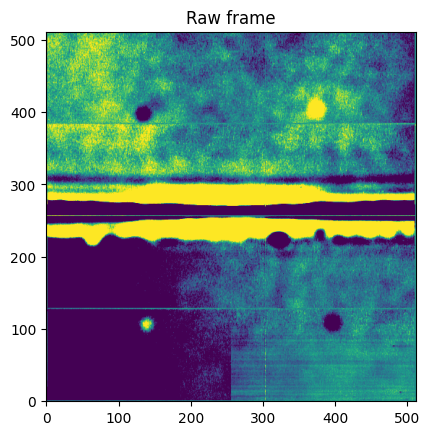

In [3]:
hdul = fits.open(raw_files[0])
hdul2 = fits.open(raw_files[1])
plt.title("Raw frame")
plt.imshow(hdul[0].data[0] - hdul2[0].data[0], origin="lower",
           vmin=-1e2, vmax=1e2)
hdul.close()
plt.show()

### Create badmap, temporary flat, and highpass filter mask

We first create a badmap to filter out dead pixels/columns, a temporary flat for use in chop state identification, and a highpass filter mask to avoid edge artifacts.

In [4]:
# This function creates the temporary flat and badmap
tempflat, badmap, _ = flat_methods.create_badmap(raw_files, smooth=30, sigma=.5)

# We create the high pass filter mask here
highpassmask = np.ones(np.shape(badmap))
highpassmask[190:310,:] = 0
highpassmask[:30,:] = 0
highpassmask[480:,:] = 0
highpassmask[:,480:] = 0
highpassmask[:,:30] = 0

# Save all three images
hdul = fits.HDUList([fits.PrimaryHDU(data=tempflat)])
hdul.writeto(obj+"_tempflat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=badmap)])
hdul.writeto(obj+"_badmap.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=highpassmask)])
hdul.writeto(obj+"_highpassmask.fits", overwrite=True)
hdul.close()

Creating integrated files for correlation...
Using a buffer of  240  frames...


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

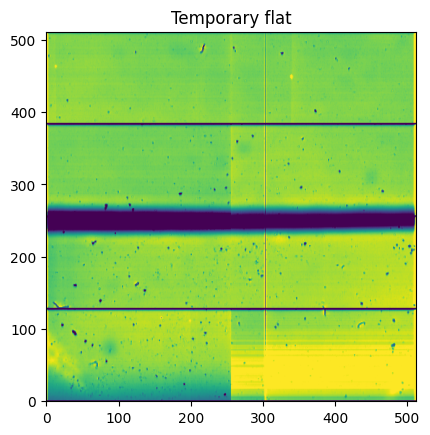

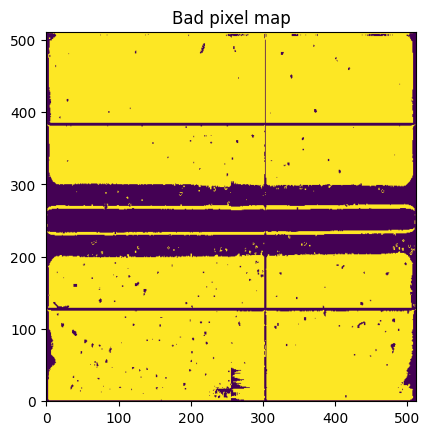

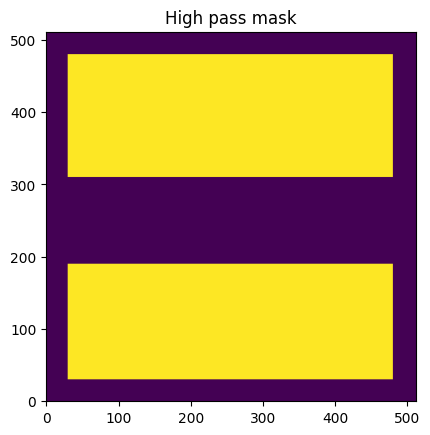

In [5]:
plt.title("Temporary flat")
plt.imshow(tempflat, origin="lower", vmin=14000, vmax=25000)
plt.show()

plt.title("Bad pixel map")
plt.imshow(badmap, origin="lower")
plt.show()

plt.title("High pass mask")
plt.imshow(highpassmask, origin="lower")
plt.show()

### Create high pass filtered frames and parallactic angles

We use the `setup_data` function to create high pass filtered frames for chop identification and obtain frame medians and parallactic angles. The chop states from the headers are also retrieved, but are usually not useful. The images/masks from earlier are inputs into this function. Frames above the default frame median limit are discarded. This function also splits the dataset into each side, SX and DX.

In [6]:
(uncorrected_files, 
 chops, 
 frame_medians,
 orig_para_angles, 
 highpass_dir) = prep.setup_data(obj, raw_dir, 
                                 highpassmask_dir = obj+"_highpassmask.fits",
                                 tempflat_dir=obj+"_tempflat.fits",
                                 badmap_dir =obj+"_badmap.fits", 
                                 use_temp_flat=True, skip_target_check=True,
                                 double_side=True, cold_stop_crop=50,
                                 binsize=5)

# Save to npz
np.savez(obj+"_NOMIC_getdata.npz", uncorrected_files, chops, frame_medians,
         orig_para_angles, highpass_dir)
print("Files saved")

Detected  240  fits files
Start frame = None
File count =  240
Reading file headers and creating high pass filtered frames...


  0%|          | 0/240 [00:00<?, ?it/s]

Files saved


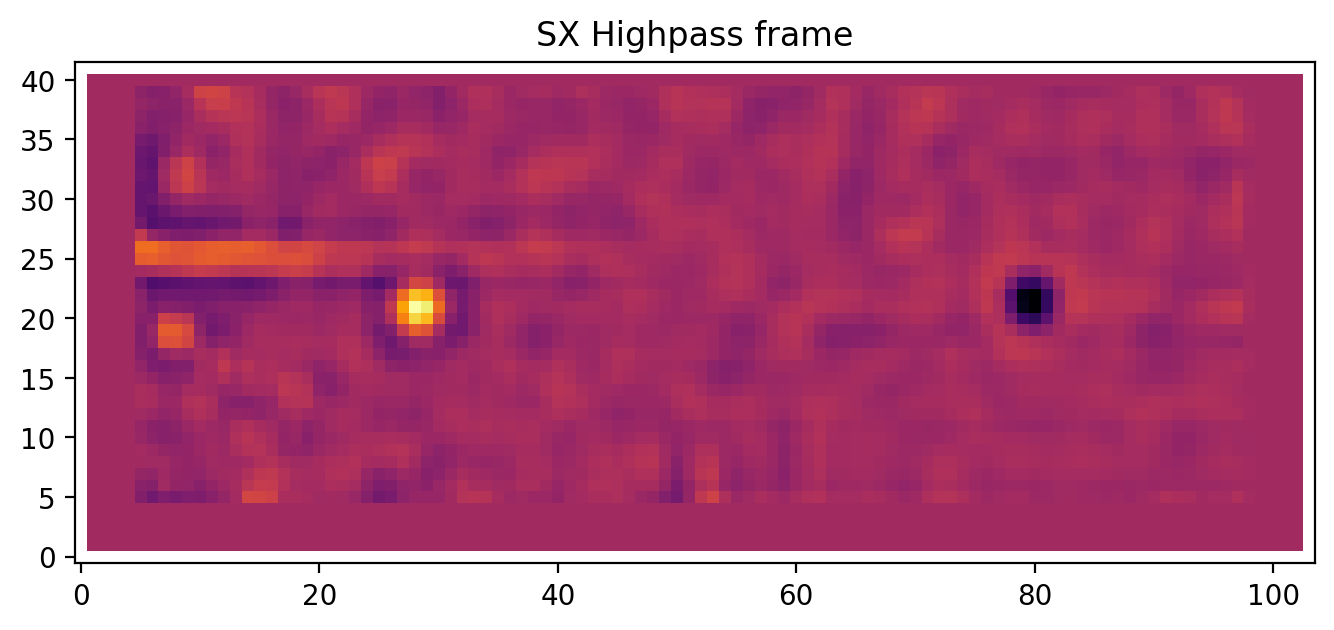

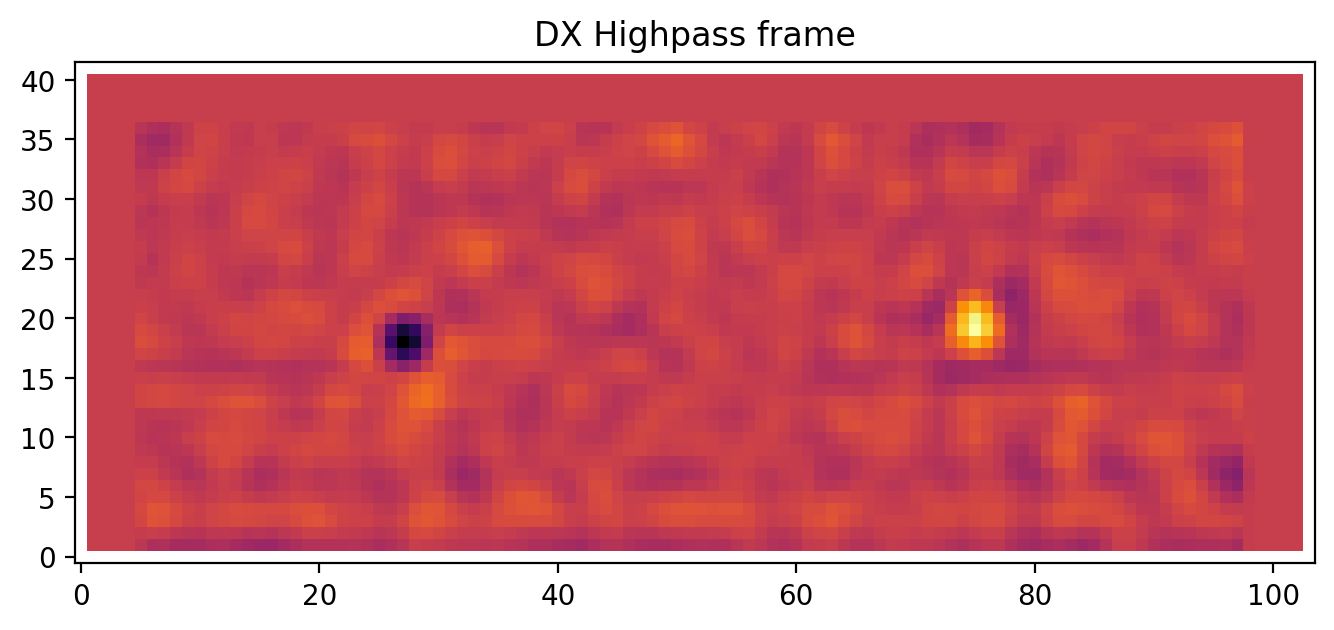

In [7]:
# Important to sort the data for reading it sequentially
sx_highpass_files = sorted(list(pathlib.Path(str(highpass_dir[0]))\
                    .rglob('*.fits')))
sx_highpass_files = np.asarray([a for a in sx_highpass_files if a.name[0]!='.'\
                             and str(a.parent)==highpass_dir[0]])

dx_highpass_files = sorted(list(pathlib.Path(str(highpass_dir[1]))\
                    .rglob('*.fits')))
dx_highpass_files = np.asarray([a for a in dx_highpass_files if a.name[0]!='.'\
                             and str(a.parent)==highpass_dir[1]])

hdul = fits.open(sx_highpass_files[0])
plt.figure(figsize=(8, 5), dpi=200)
plt.title("SX Highpass frame")
plt.imshow(hdul[0].data, origin="lower", cmap="inferno")
hdul.close()
plt.show()

hdul = fits.open(dx_highpass_files[0])
plt.figure(figsize=(8, 5), dpi=200)
plt.title("DX Highpass frame")
plt.imshow(hdul[0].data, origin="lower", cmap="inferno")
hdul.close()
plt.show()

### Identify chops and create coadded frames

Using our highpass filtered data, we identify the chop states of all the raw images and coadd any consecutive chops as necessary. We also edit our file list and parallactic angles to match the list. The coadded frames are saved in a separate directory and the file list is amended to include the coadded frames and exclude the parent raw frames.

In [8]:
(sx_files,
 sx_chops,
 sx_para_angles,
 sx_maxima,
 sx_orig_chops,
 sx_orig_maxima) = prep.chop_correction(uncorrected_files[0], chops,
                                        orig_para_angles, str(highpass_dir[0]), 
                                        chop_direction="LEFT-RIGHT")

np.savez(obj+"_SX_NOMIC_chop_correction.npz", sx_files, sx_chops,
         sx_para_angles, sx_maxima, sx_orig_chops, sx_orig_maxima)

(dx_files,
 dx_chops,
 dx_para_angles,
 dx_maxima, 
 dx_orig_chops,
 dx_orig_maxima) = prep.chop_correction(uncorrected_files[1], chops,
                                        orig_para_angles, str(highpass_dir[1]),
                                        chop_direction="LEFT-RIGHT")

np.savez(obj+"_DX_NOMIC_chop_correction.npz", dx_files, dx_chops,
         dx_para_angles, dx_maxima, dx_orig_chops, dx_orig_maxima)

print("Files saved")

Finding chop positions....


  0%|          | 0/240 [00:00<?, ?it/s]

Finding consecutive repeat chop positions...


0it [00:00, ?it/s]

Coadding consecutive repeat chop positions...


...

Finding consecutive repeat chop positions...


0it [00:00, ?it/s]

Coadding consecutive repeat chop positions...


  0%|          | 0/1 [00:00<?, ?it/s]

Files saved


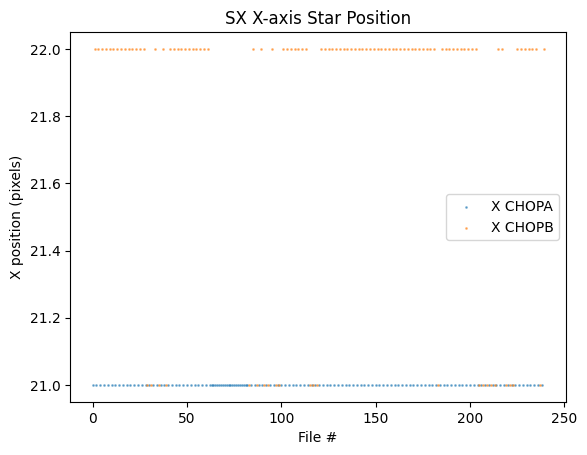

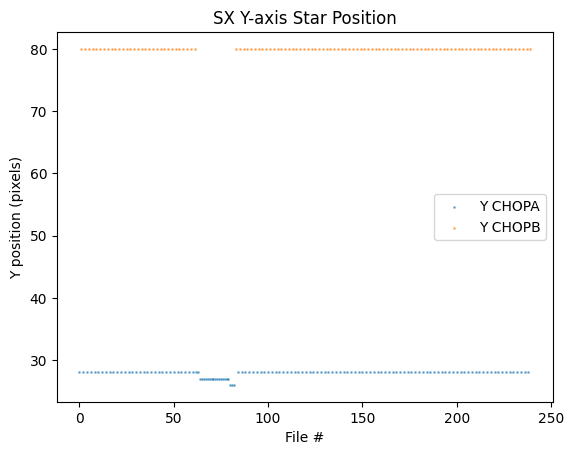

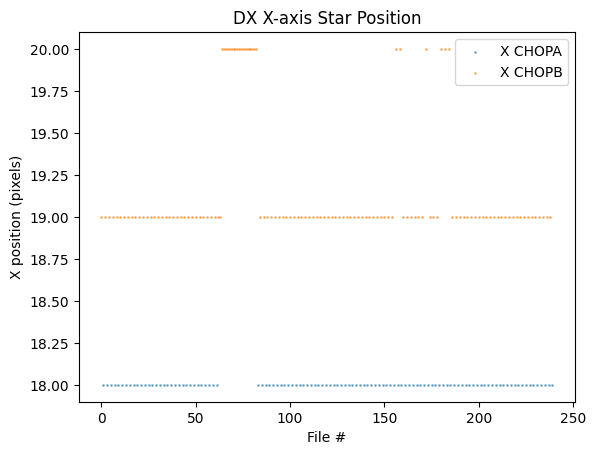

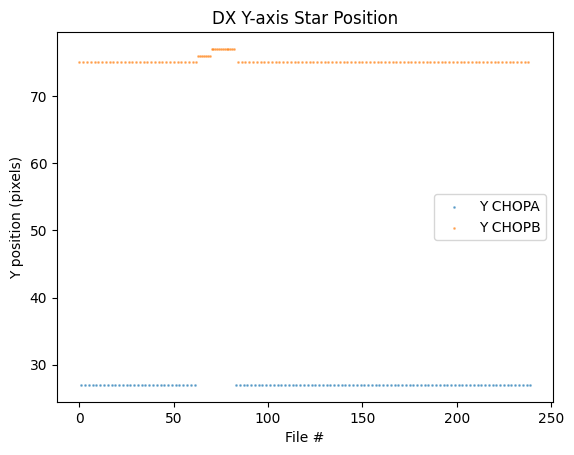

In [9]:
plt.title("SX X-axis Star Position")
plt.scatter(np.arange(len(sx_orig_maxima))[sx_orig_chops == "CHOP_A"],
            sx_orig_maxima[:,0][sx_orig_chops == "CHOP_A"],
            label="X CHOPA", s=1, alpha=0.5)
plt.scatter(np.arange(len(sx_orig_maxima))[sx_orig_chops == "CHOP_B"],
            sx_orig_maxima[:,0][sx_orig_chops == "CHOP_B"],
            label="X CHOPB", s=1, alpha=0.5)
plt.legend(loc="best")
plt.xlabel("File #")
plt.ylabel("X position (pixels)")
plt.show()

plt.title("SX Y-axis Star Position")
plt.scatter(np.arange(len(sx_orig_maxima))[sx_orig_chops == "CHOP_A"],
            sx_orig_maxima[:,1][sx_orig_chops == "CHOP_A"],
            label="Y CHOPA", s=1, alpha=0.5)
plt.scatter(np.arange(len(sx_orig_maxima))[sx_orig_chops == "CHOP_B"],
            sx_orig_maxima[:,1][sx_orig_chops == "CHOP_B"],
            label="Y CHOPB", s=1, alpha=0.5)
plt.legend(loc="best")
plt.xlabel("File #")
plt.ylabel("Y position (pixels)")
plt.show()

plt.title("DX X-axis Star Position")
plt.scatter(np.arange(len(dx_orig_maxima))[dx_orig_chops == "CHOP_A"],
            dx_orig_maxima[:,0][dx_orig_chops == "CHOP_A"],
            label="X CHOPA", s=1, alpha=0.5)
plt.scatter(np.arange(len(dx_orig_maxima))[dx_orig_chops == "CHOP_B"],
            dx_orig_maxima[:,0][dx_orig_chops == "CHOP_B"],
            label="X CHOPB", s=1, alpha=0.5)
plt.legend(loc="best")
plt.xlabel("File #")
plt.ylabel("X position (pixels)")
plt.show()

plt.title("DX Y-axis Star Position")
plt.scatter(np.arange(len(dx_orig_maxima))[dx_orig_chops == "CHOP_A"],
            dx_orig_maxima[:,1][dx_orig_chops == "CHOP_A"],
            label="Y CHOPA", s=1, alpha=0.5)
plt.scatter(np.arange(len(dx_orig_maxima))[dx_orig_chops == "CHOP_B"],
            dx_orig_maxima[:,1][dx_orig_chops == "CHOP_B"],
            label="Y CHOPB", s=1, alpha=0.5)
plt.legend(loc="best")
plt.xlabel("File #")
plt.ylabel("Y position (pixels)")
plt.show()

### Create more flats!

The temporary flat we created earlier was a good proxy for identifying chop states, but now that we have the chop states, we can construct a better flat that omits the stellar PSF for each chop state. First, we create new bad pixel maps for each side. Then, we create a "combined" flat with the function `create_stacked_flat` that uses the halves of the image from each chop state that do not have the stellar PSF and stitch them together into a single flat for the whole dataset. This flat is used to help the function `subtract_psfs` create versions of the frames without the PSF.

In [10]:
_, sx_badmap, _ = flat_methods.create_badmap(sx_files, smooth=30, sigma=1)
_, dx_badmap, _ = flat_methods.create_badmap(dx_files, smooth=30, sigma=1)

(sx_combined_flat,
 sx_chopa_part,
 sx_chopb_part) = flat_methods.create_stacked_flat(sx_files, sx_chops,
                                                   chop_direction="LEFT-RIGHT",
                                                   tolerance=0.2)

(dx_combined_flat,
 dx_chopa_part,
 dx_chopb_part) = flat_methods.create_stacked_flat(dx_files, dx_chops,
                                                   chop_direction="LEFT-RIGHT",
                                                   tolerance=0.2)

hdul = fits.HDUList([fits.PrimaryHDU(data=sx_badmap)])
hdul.writeto(obj+"_SX_badmap.fits", overwrite=True)
hdul.close()
hdul = fits.HDUList([fits.PrimaryHDU(data=dx_badmap)])
hdul.writeto(obj+"_DX_badmap.fits", overwrite=True)
hdul.close()
hdul = fits.HDUList([fits.PrimaryHDU(data=sx_combined_flat)])
hdul.writeto(obj+"_SX_combinedflat.fits", overwrite=True)
hdul.close()
hdul = fits.HDUList([fits.PrimaryHDU(data=dx_combined_flat)])
hdul.writeto(obj+"_DX_combinedflat.fits", overwrite=True)
hdul.close()

Creating integrated files for correlation...
Using a buffer of  220  frames...


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

Creating integrated files for correlation...
Using a buffer of  220  frames...


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

Creating integrated files for correlation...
Using a buffer of  110  frames...


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

Creating integrated files for correlation...
Using a buffer of  110  frames...


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

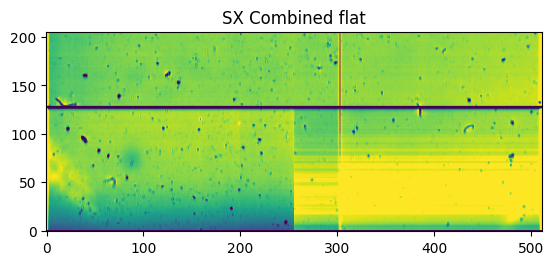

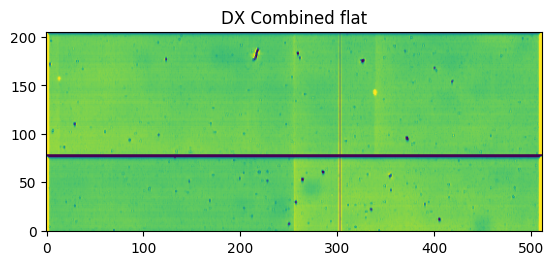

In [11]:
plt.title("SX Combined flat")
plt.imshow(sx_combined_flat, origin="lower", vmin=16000, vmax=25000)
plt.show()
plt.title("DX Combined flat")
plt.imshow(dx_combined_flat, origin="lower", vmin=16000, vmax=25000)
plt.show()

### Subtract PSFs to aid background subtraction/calibration

We can now model and subtract the PSF from the images to create even better flats for each chop state. We can also use these PSF subtracted images for chop subtraction.

In [13]:
(sx_psf_subtracted_dir,
 maxima) = flat_methods.subtract_psfs(sx_files, sx_chops, sx_maxima,
                                      stellar_temp, flat=sx_combined_flat,
                                      badmap=sx_badmap, remove_residual=False,
                                      remove_trefoil=False, prefix="sx_")

(dx_psf_subtracted_dir,
 maxima) = flat_methods.subtract_psfs(dx_files, dx_chops, dx_maxima,
                                      stellar_temp, flat=dx_combined_flat,
                                      badmap=dx_badmap, remove_residual=False,
                                      remove_trefoil=False, prefix="dx_")

Subtracting psfs....


  0%|          | 0/220 [00:00<?, ?it/s]

C:\Users\mmc\Music\Project\BetaLeo7\pyNOMIC\helper_functions.py:560: RuntimeWarning: invalid value encountered in divide
  model = (amp/(1-e**2)**2) * (2*j1(rad)/rad - 2*e*j1(e*rad)/rad)**2 + offset


Subtracting psfs....


  0%|          | 0/220 [00:00<?, ?it/s]

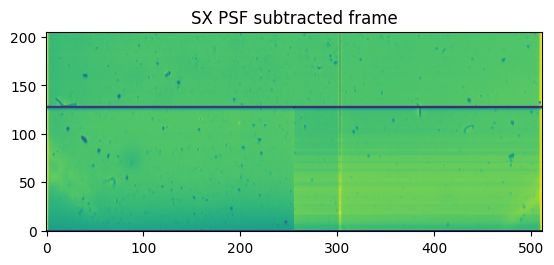

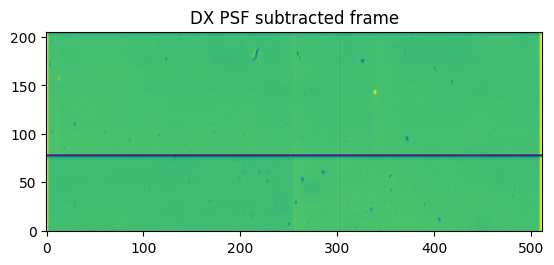

In [14]:
# Important to sort the data for reading it sequentially
sx_psf_subtracted_files = sorted(list(pathlib.Path(str(sx_psf_subtracted_dir))\
                       .rglob('*.fits')))
sx_psf_subtracted_files = np.asarray([a for a in sx_psf_subtracted_files\
                                   if a.name[0]!='.'\
                                   and str(a.parent)==sx_psf_subtracted_dir])

dx_psf_subtracted_files = sorted(list(pathlib.Path(str(dx_psf_subtracted_dir))\
                       .rglob('*.fits')))
dx_psf_subtracted_files = np.asarray([a for a in dx_psf_subtracted_files\
                                   if a.name[0]!='.'\
                                   and str(a.parent)==dx_psf_subtracted_dir])

hdul = fits.open(sx_psf_subtracted_files[1])
plt.title("SX PSF subtracted frame")
plt.imshow(hdul[0].data, origin="lower")
hdul.close()
plt.show()

hdul = fits.open(dx_psf_subtracted_files[1])
plt.title("DX PSF subtracted frame")
plt.imshow(hdul[0].data, origin="lower")
hdul.close()
plt.show()

In [15]:
_, sx_chopa_flat, sx_chopb_flat =\
    flat_methods.create_stacked_flat(sx_psf_subtracted_files, sx_chops,
                                    chop_direction="LEFT-RIGHT", tolerance=0.2)

_, dx_chopa_flat, dx_chopb_flat =\
    flat_methods.create_stacked_flat(dx_psf_subtracted_files, dx_chops,
                                    chop_direction="LEFT-RIGHT", tolerance=0.2)

hdul = fits.HDUList([fits.PrimaryHDU(data=sx_chopa_flat)])
hdul.writeto(obj+"_SX_chopaflat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=sx_chopb_flat)])
hdul.writeto(obj+"_SX_chopbflat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=dx_chopa_flat)])
hdul.writeto(obj+"_DX_chopaflat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=dx_chopb_flat)])
hdul.writeto(obj+"_DX_chopbflat.fits", overwrite=True)
hdul.close()
print("Flats saved")

Creating integrated files for correlation...
Using a buffer of  55  frames...


integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

Creating integrated files for correlation...
Using a buffer of  55  frames...


integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

Flats saved


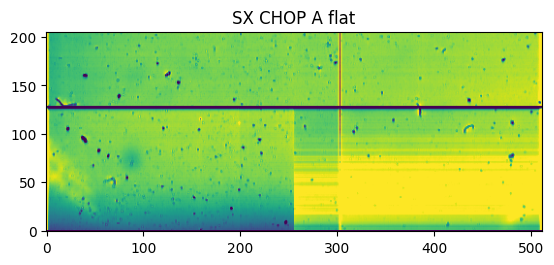

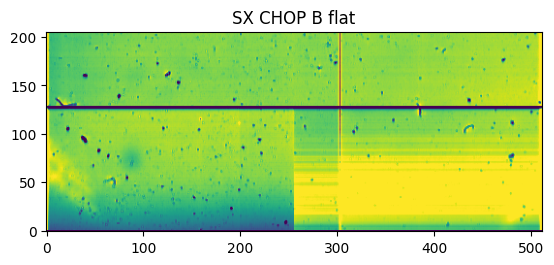

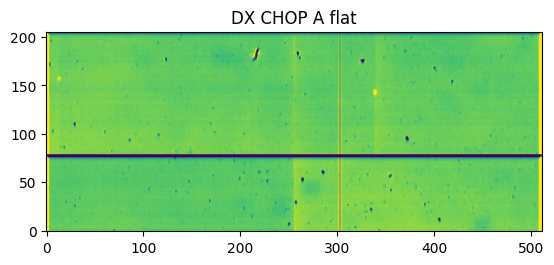

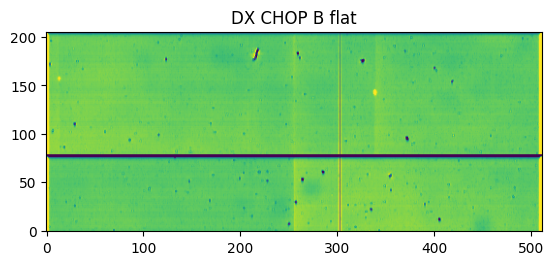

In [16]:
plt.title("SX CHOP A flat")
plt.imshow(sx_chopa_flat, origin="lower", vmin=16000, vmax=25000)
plt.show()
plt.title("SX CHOP B flat")
plt.imshow(sx_chopb_flat, origin="lower", vmin=16000, vmax=25000)
plt.show()
plt.title("DX CHOP A flat")
plt.imshow(dx_chopa_flat, origin="lower", vmin=16000, vmax=25000)
plt.show()
plt.title("DX CHOP B flat")
plt.imshow(dx_chopb_flat, origin="lower", vmin=16000, vmax=25000)
plt.show()

### Background subtraction

We now create background subtracted (and flat calibrated) images, with some image repair as well to deal with NOMIC systematics (striped regions, biases). These images are saved in a directory.

In [17]:
sx_subtracted_dir = prep.subtract_background(sx_files, sx_psf_subtracted_files,
                                             sx_chops, flats=[sx_chopa_flat,
                                                              sx_chopb_flat],
                                             prefix="sx_", channel_edges=[127],
                                             biased_columns=[303],
                                             striped_regions=[[0, 124, 255,
                                                               304, -3],
                                                              [0, 124, 304,
                                                               -3, -3]],
                                             vertical_biases=[256])
                        
dx_subtracted_dir = prep.subtract_background(dx_files, dx_psf_subtracted_files,
                                             dx_chops, flats=[dx_chopa_flat,
                                                              dx_chopb_flat],
                                             prefix="dx_", channel_edges=[77],
                                             biased_columns=[303],
                                             horizontal_biases=[77])

#shutil.rmtree(str(sx_highpass_dir))
#shutil.rmtree(str(dx_highpass_dir))

Subtracting backgrounds....


  0%|          | 0/220 [00:00<?, ?it/s]

C:\Users\mmc\Music\Project\BetaLeo7\pyNOMIC\helper_functions.py:428: RuntimeWarning: Mean of empty slice
  offsets = np.nanmean(ref[:,int(loc - 6):int(loc - 1)] -


Subtracting backgrounds....


  0%|          | 0/220 [00:00<?, ?it/s]

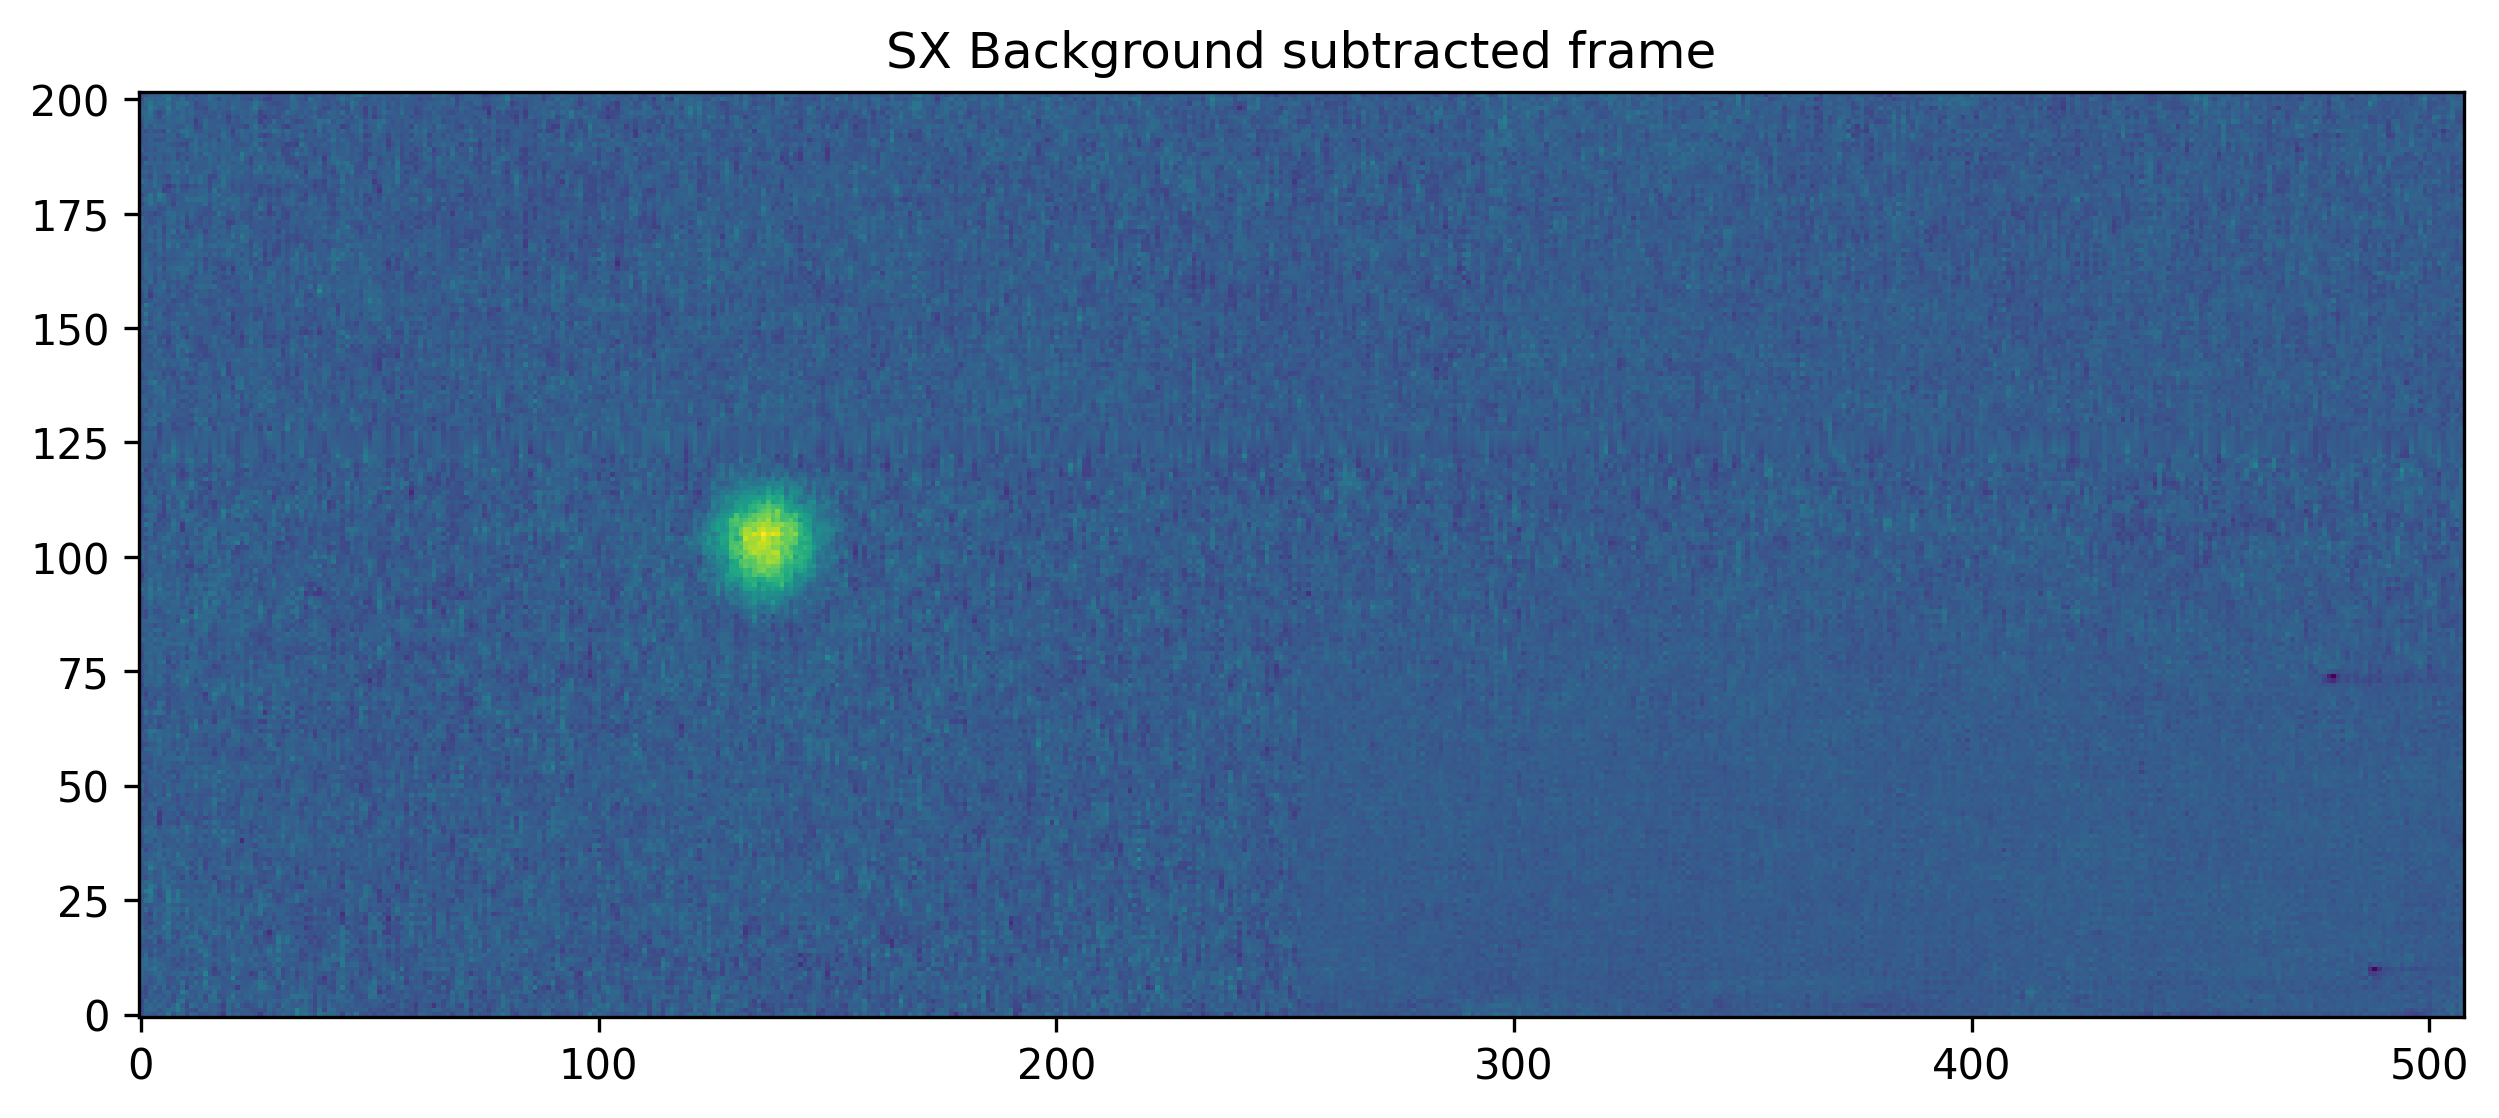

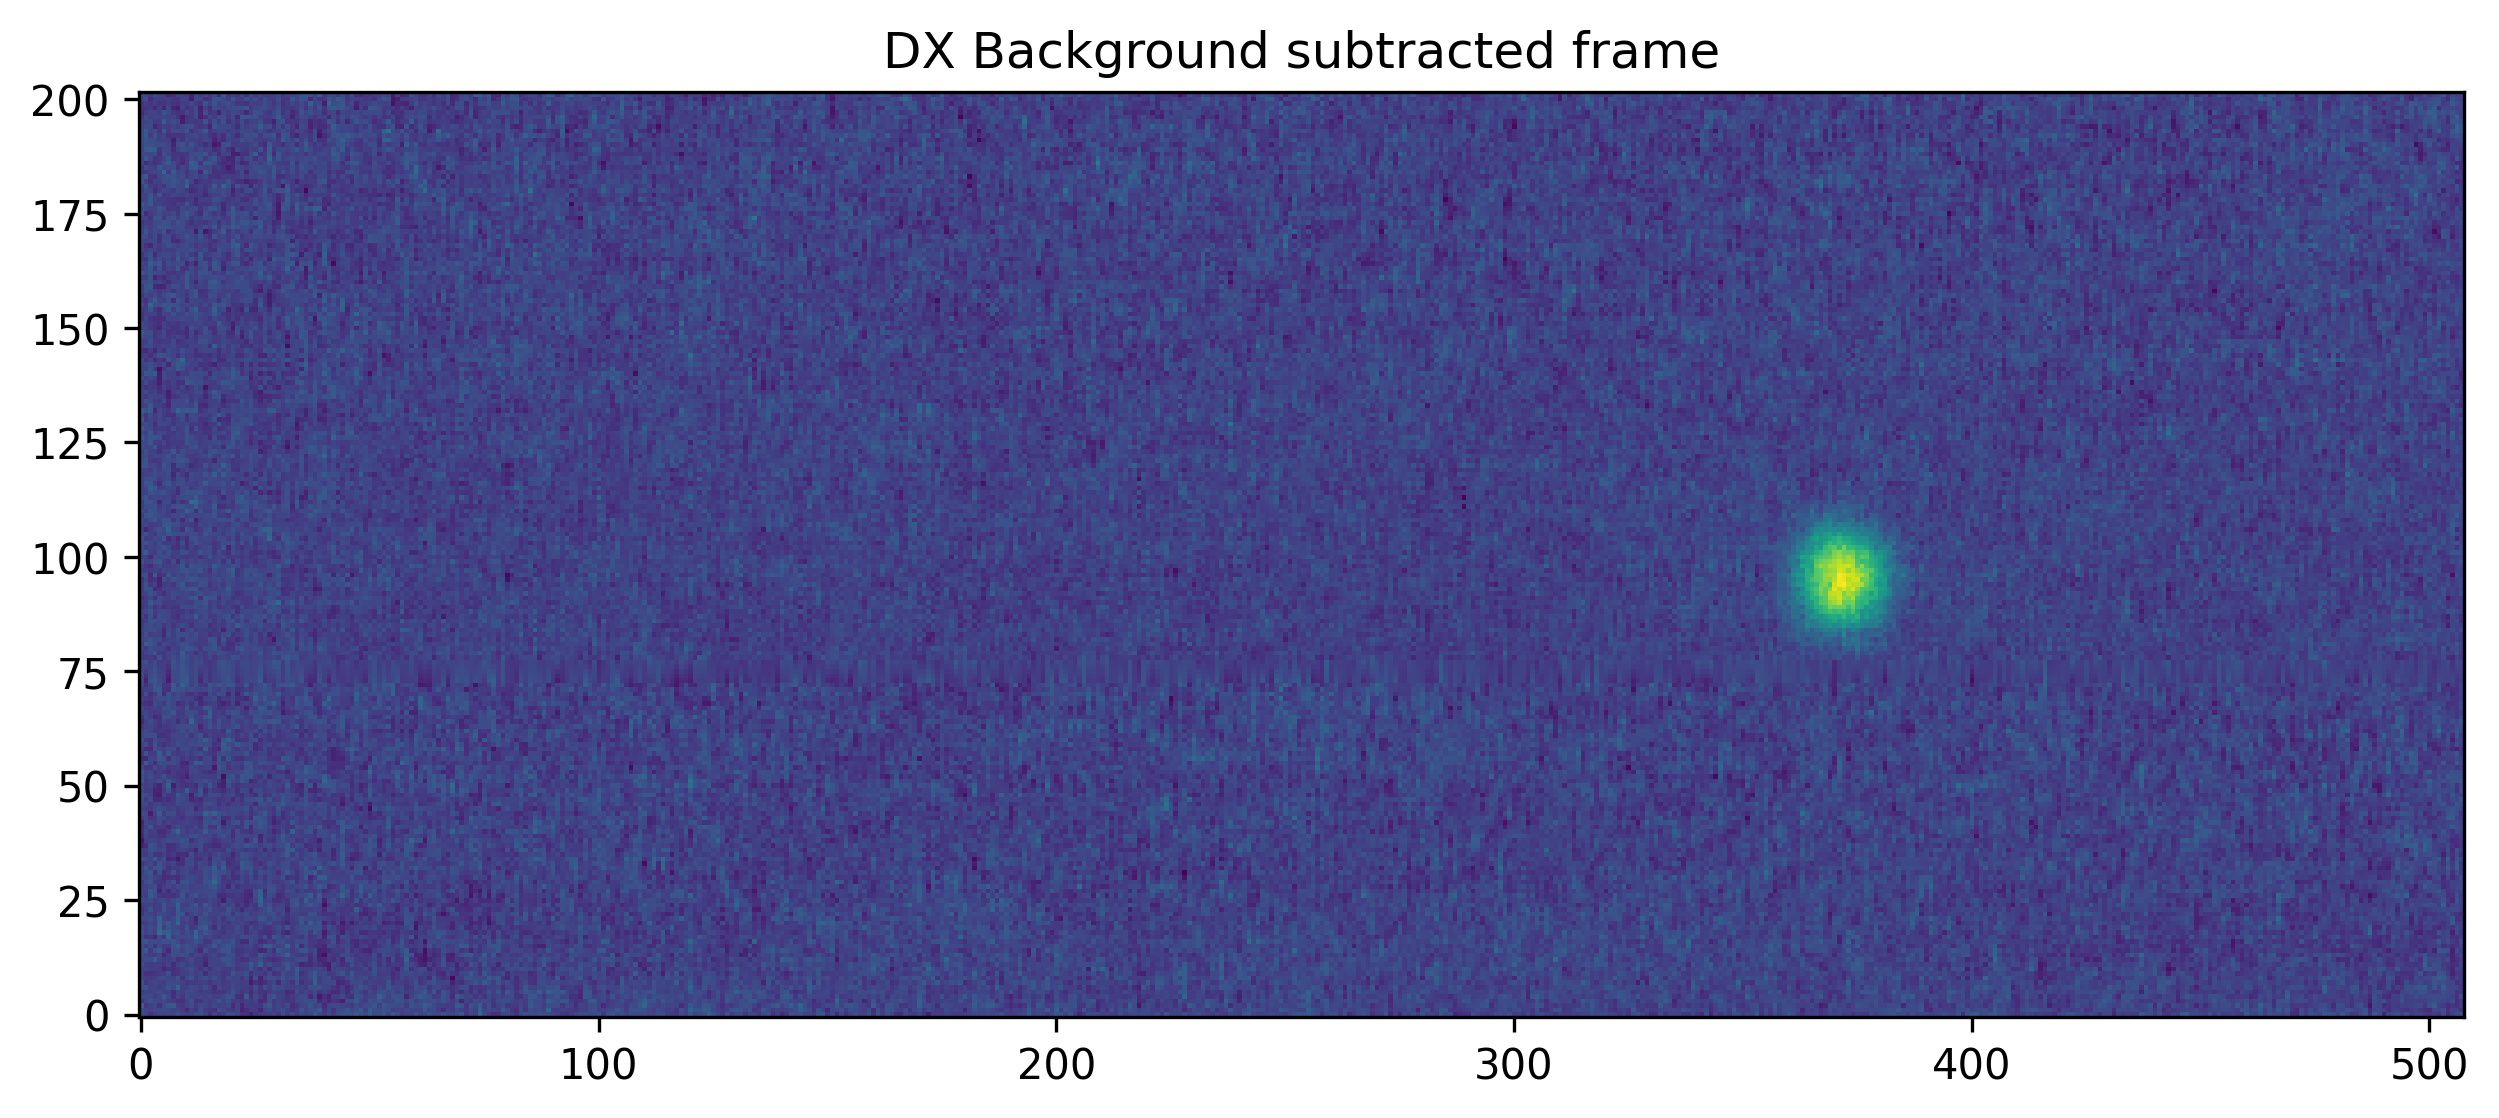

In [18]:
# Important to sort the data for reading it sequentially
sx_subtracted_files = sorted(list(pathlib.Path(str(sx_subtracted_dir))\
                       .rglob('*.fits')))
sx_subtracted_files = np.asarray([a for a in sx_subtracted_files\
                                   if a.name[0]!='.'\
                                   and str(a.parent)==sx_subtracted_dir])

dx_subtracted_files = sorted(list(pathlib.Path(str(dx_subtracted_dir))\
                       .rglob('*.fits')))
dx_subtracted_files = np.asarray([a for a in dx_subtracted_files\
                                   if a.name[0]!='.'\
                                   and str(a.parent)==dx_subtracted_dir])

hdul = fits.open(sx_subtracted_files[0])
sx_img = hdul[0].data
hdul.close()
hdul = fits.open(dx_subtracted_files[0])
dx_img = hdul[0].data
hdul.close()

plt.figure(figsize=(10,10), dpi=300)
plt.title("SX Background subtracted frame")
plt.imshow(sx_img, origin="lower")#, vmin=-5e-3, vmax=5e-3)
plt.show()

plt.figure(figsize=(10,10), dpi=300)
plt.title("DX Background subtracted frame")
plt.imshow(dx_img, origin="lower")#, vmin=-5e-3, vmax=5e-3)
plt.show()

### Frame registration
We now align the frames and place the PSFs at the center of the image. We obtain other parameters as well, including image characteristics and gaussian model fits.

In [19]:
(sx_original_psf_locs,
 sx_reffit,
 sx_array_shape,
 sx_file_size,
 sx_aligned_files) = prep.frame_registration(sx_files, sx_subtracted_dir,
                                             stellar_temp=stellar_temp,
                                             prefix="sx_")

(dx_original_psf_locs,
 dx_reffit,
 dx_array_shape,
 dx_file_size,
 dx_aligned_files) = prep.frame_registration(dx_files, dx_subtracted_dir,
                                             stellar_temp=stellar_temp,
                                             prefix="dx_")

#shutil.rmtree(sx_subtracted_dir)
#shutil.rmtree(dx_subtracted_dir)

np.savez(obj+"_SX_NOMIC_aligned.npz", sx_aligned_files, sx_original_psf_locs,
         sx_reffit, sx_array_shape, sx_file_size)
np.savez(obj+"_DX_NOMIC_aligned.npz", dx_aligned_files, dx_original_psf_locs, 
         dx_reffit, dx_array_shape, dx_file_size)

print("Files saved")

Aligning frames....


  0%|          | 0/218 [00:00<?, ?it/s]

Aligning frames....


  0%|          | 0/218 [00:00<?, ?it/s]

Files saved


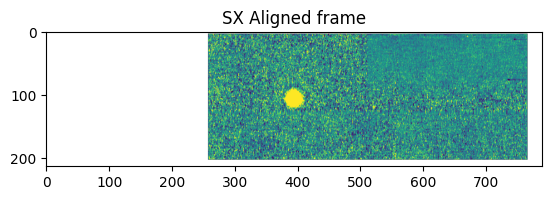

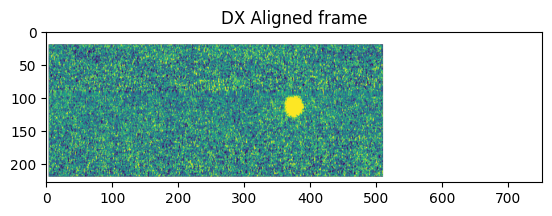

In [20]:
plt.title("SX Aligned frame")
hdul = fits.open(sx_aligned_files[0])
plt.imshow(hdul[0].data, vmin=-2e-3, vmax=2e-3)
hdul.close()
plt.show()

plt.title("DX Aligned frame")
hdul = fits.open(dx_aligned_files[0])
plt.imshow(hdul[0].data, vmin=-2e-3, vmax=2e-3)
hdul.close()
plt.show()

### Frame evaluation
We now evaluate the frames to get properties including fwhms, background deviation, maxima, etc.

In [21]:
(sx_fwhms, 
 sx_eccentricities,
 sx_psfmaxima,
 sx_background_dev,
 sx_correlations, 
 sx_amplitudes,
 sx_offsets,
 sx_assumed_apertures,
 sx_axis_ratios,
 sx_residual_dev,
 sx_sigmax, 
 sx_sigmay,
 _) = prep.frame_evaluation(sx_aligned_files, sx_chops, sx_array_shape,
                            sx_file_size, stellar_temp, tolerance=0.2)

(dx_fwhms,
 dx_eccentricities,
 dx_psfmaxima,
 dx_background_dev,
 dx_correlations,
 dx_amplitudes,
 dx_offsets,
 dx_assumed_apertures,
 dx_axis_ratios,
 dx_residual_dev,
 dx_sigmax,
 dx_sigmay,
 _) = prep.frame_evaluation(dx_aligned_files, dx_chops, dx_array_shape,
                            dx_file_size, stellar_temp, tolerance=0.2)

np.savez(obj+"_SX_NOMIC_evaluated.npz", sx_fwhms, sx_eccentricities,
         sx_psfmaxima, sx_background_dev, sx_correlations, sx_amplitudes,
         sx_offsets, sx_assumed_apertures, sx_axis_ratios, sx_residual_dev,
         sx_sigmax, sx_sigmay)

np.savez(obj+"_DX_NOMIC_evaluated.npz", dx_fwhms, dx_eccentricities,
         dx_psfmaxima, dx_background_dev, dx_correlations, dx_amplitudes,
         dx_offsets, dx_assumed_apertures, dx_axis_ratios, dx_residual_dev,
         dx_sigmax, dx_sigmay)

print("Files saved")

Creating integrated files for correlation...
Using a buffer of  55  frames...


integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

C:\Users\mmc\Music\Project\BetaLeo7\pyNOMIC\helper_functions.py:73: RuntimeWarning: Mean of empty slice
  stacked_img = np.nanmean(buf_3D, axis=0)*count


integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/220 [00:00<?, ?it/s]

...

C:\Users\mmc\Music\Project\BetaLeo7\pyNOMIC\preprocessing.py:1976: RuntimeWarning: invalid value encountered in sqrt
  eccentricities = np.sqrt(1 - sigmax/sigmay)
C:\Users\mmc\Music\Project\BetaLeo7\pyNOMIC\preprocessing.py:1977: RuntimeWarning: invalid value encountered in sqrt
  eccentricities_r = np.sqrt(1 - sigmay/sigmax)


integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

integrating files:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/220 [00:00<?, ?it/s]

Files saved


### Frame rejection and binning
We can do a first round of rejection using frame properties, and then bin the frames and obtain the binned frame properties.

In [22]:
sx_frame_bool = prep.frame_rejection(sx_chops,
                                     [sx_fwhms, sx_eccentricities,
                                      -1*sx_psfmaxima, sx_background_dev,
                                      -1*sx_correlations, -1*sx_amplitudes,
                                      sx_offsets, sx_assumed_apertures,
                                      sx_axis_ratios, sx_residual_dev])

dx_frame_bool = prep.frame_rejection(dx_chops,
                                     [dx_fwhms, dx_eccentricities,
                                      -1*dx_psfmaxima, dx_background_dev,
                                      -1*dx_correlations, -1*dx_amplitudes,
                                      dx_offsets, dx_assumed_apertures,
                                      dx_axis_ratios, dx_residual_dev])

(sx_binned_files,
 sx_binned_chops,
 sx_binned_angles) = prep.frame_binning(sx_aligned_files, sx_chops,
                                        sx_para_angles, sx_frame_bool,
                                        sx_array_shape, prefix="sx_", bin=50)

(dx_binned_files,
 dx_binned_chops,
 dx_binned_angles) = prep.frame_binning(dx_aligned_files, dx_chops,
                                        dx_para_angles, dx_frame_bool,
                                        dx_array_shape, prefix="dx_", bin=50)

(sx_binned_fwhms,
 sx_binned_eccs,
 sx_binned_psfmax,
 sx_binned_backdev,
 sx_binned_corrs,
 sx_binned_amps,
 sx_binned_offsets,
 sx_binned_aps,
 sx_binned_axis_ratios,
 sx_binned_residual_dev,
 sx_binned_sigmax,
 sx_binned_sigmay,
 _) = prep.frame_evaluation(sx_binned_files, sx_binned_chops, sx_array_shape,
                            sx_file_size, stellar_temp=stellar_temp,
                            tolerance=0.2)

(dx_binned_fwhms,
 dx_binned_eccs,
 dx_binned_psfmax,
 dx_binned_backdev,
 dx_binned_corrs,
 dx_binned_amps,
 dx_binned_offsets,
 dx_binned_aps,
 dx_binned_axis_ratios,
 dx_binned_residual_dev,
 dx_binned_sigmax, 
 dx_binned_sigmay,
 _) = prep.frame_evaluation(dx_binned_files, dx_binned_chops, dx_array_shape,
                            dx_file_size, stellar_temp=stellar_temp,
                            tolerance=0.2)

np.savez(obj+"_NOMIC_binned_evaluated.npz", sx_binned_fwhms, sx_binned_eccs,
         sx_binned_psfmax, sx_binned_backdev, sx_binned_corrs, sx_binned_amps,
         sx_binned_offsets, sx_binned_aps, sx_binned_axis_ratios, 
         sx_binned_residual_dev, sx_binned_sigmax, sx_binned_sigmay,
         sx_binned_files, sx_binned_chops, sx_binned_angles)

np.savez(obj+"_NOMIC_binned_evaluated.npz", dx_binned_fwhms, dx_binned_eccs,
         dx_binned_psfmax, dx_binned_backdev, dx_binned_corrs, dx_binned_amps,
         dx_binned_offsets, dx_binned_aps, dx_binned_axis_ratios, 
         dx_binned_residual_dev, dx_binned_sigmax, dx_binned_sigmay,
         dx_binned_files, dx_binned_chops, dx_binned_angles)

print("Files saved")

Binning files...


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Binning files...


0it [00:00, ?it/s]

...

Creating integrated files for correlation...
Using a buffer of  1  frames...


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Files saved


### Frame rejection and binning
We can do a second round of rejection to obtain the final image cube.

In [23]:
sx_binned_frame_bool = prep.frame_rejection(sx_binned_chops, 
                                            [-1*sx_binned_psfmax,
                                             sx_binned_backdev])

dx_binned_frame_bool = prep.frame_rejection(dx_binned_chops,
                                            [-1*dx_binned_psfmax,
                                             dx_binned_backdev])

sx_image_cube = np.zeros((len(sx_binned_files[sx_binned_frame_bool]),
                          sx_array_shape[0], sx_array_shape[1]))

for i in tqdm(range(len(sx_image_cube))):
    hdul = fits.open(sx_binned_files[sx_binned_frame_bool][i])
    sx_image_cube[i] = hdul[0].data
    hdul.close()

dx_image_cube = np.zeros((len(dx_binned_files[dx_binned_frame_bool]),
                          dx_array_shape[0], dx_array_shape[1]))

for i in tqdm(range(len(dx_image_cube))):
    hdul = fits.open(dx_binned_files[dx_binned_frame_bool][i])
    dx_image_cube[i] = hdul[0].data
    hdul.close()

C:\Users\mmc\Music\Project\BetaLeo7\pyNOMIC\preprocessing.py:2021: RuntimeWarning: divide by zero encountered in scalar divide
  params[i][chopa_bool] *= np.nanstd(params[i][chopb_bool])/np.nanstd(params[i][chopa_bool])
C:\Users\mmc\Music\Project\BetaLeo7\pyNOMIC\preprocessing.py:2022: RuntimeWarning: invalid value encountered in add
  params[i][chopa_bool] += np.nanmedian(params[i][chopb_bool]) -\


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

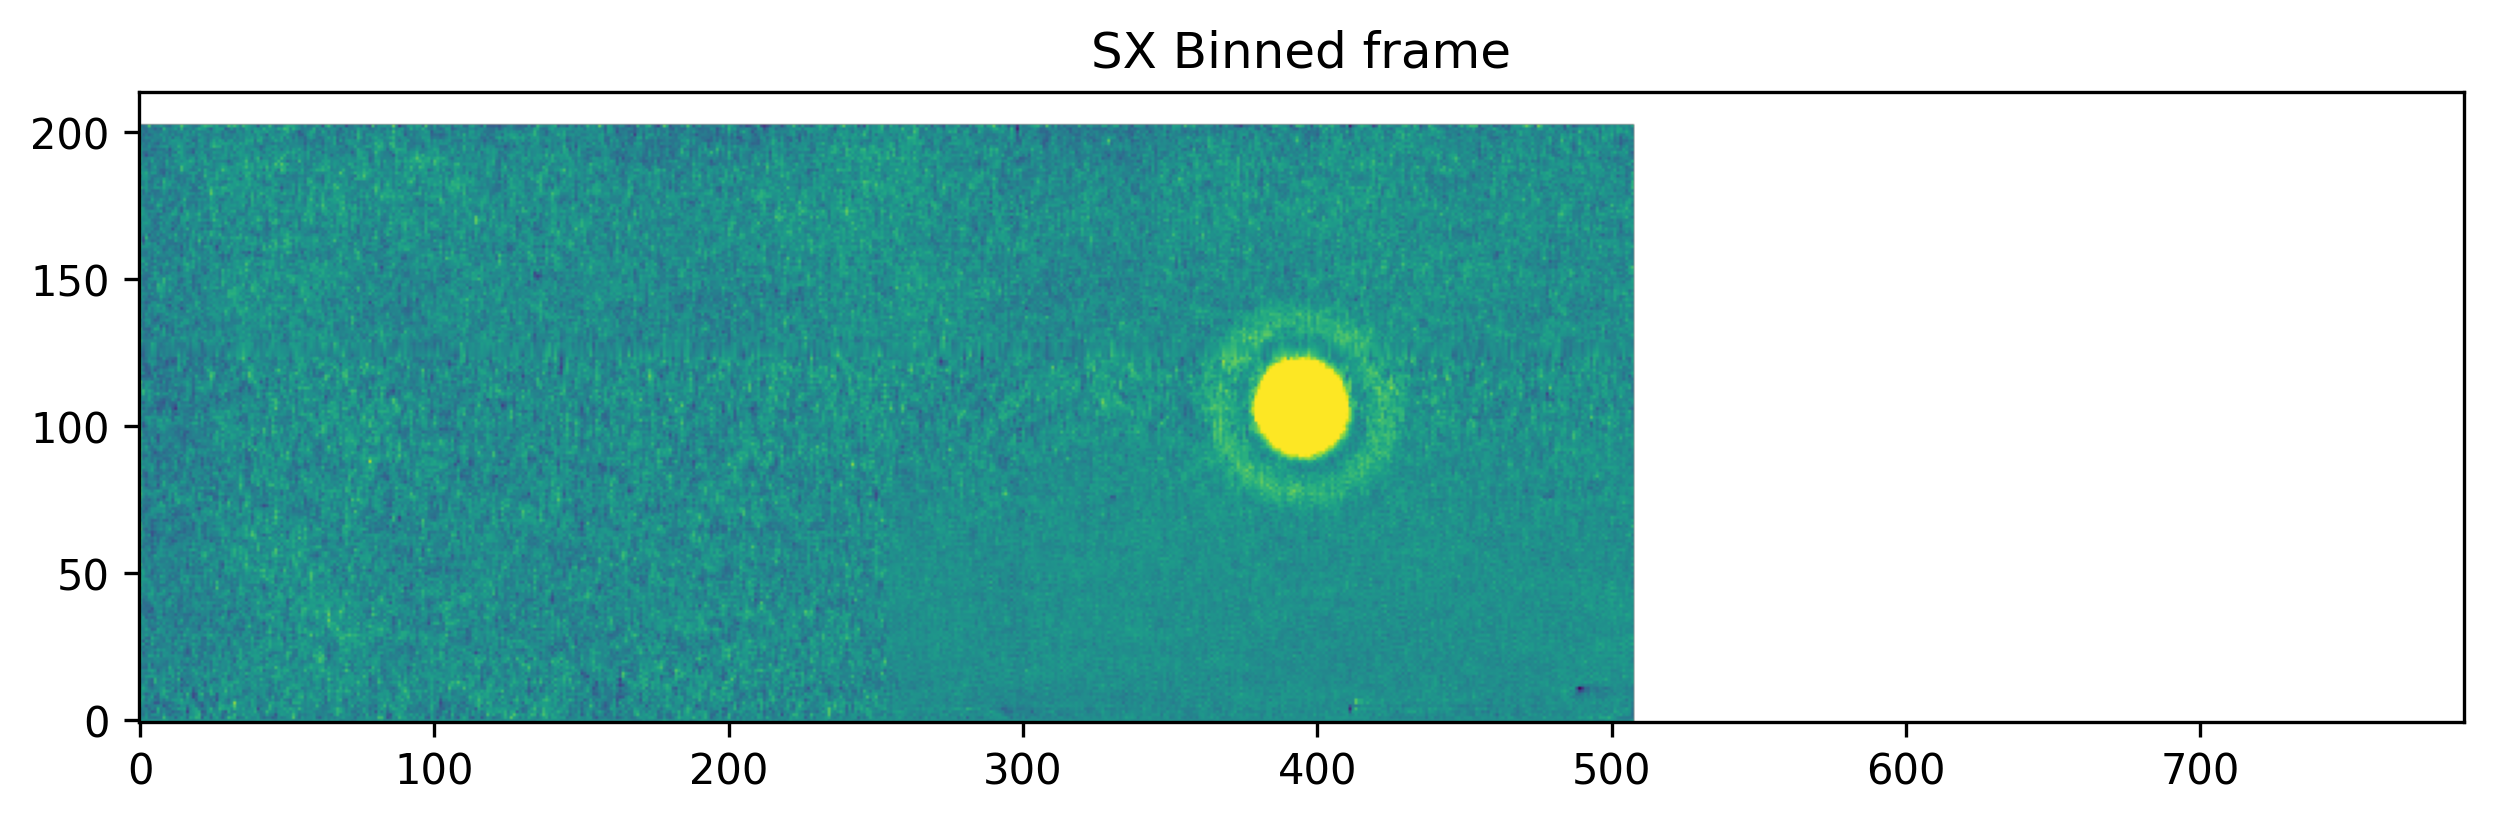

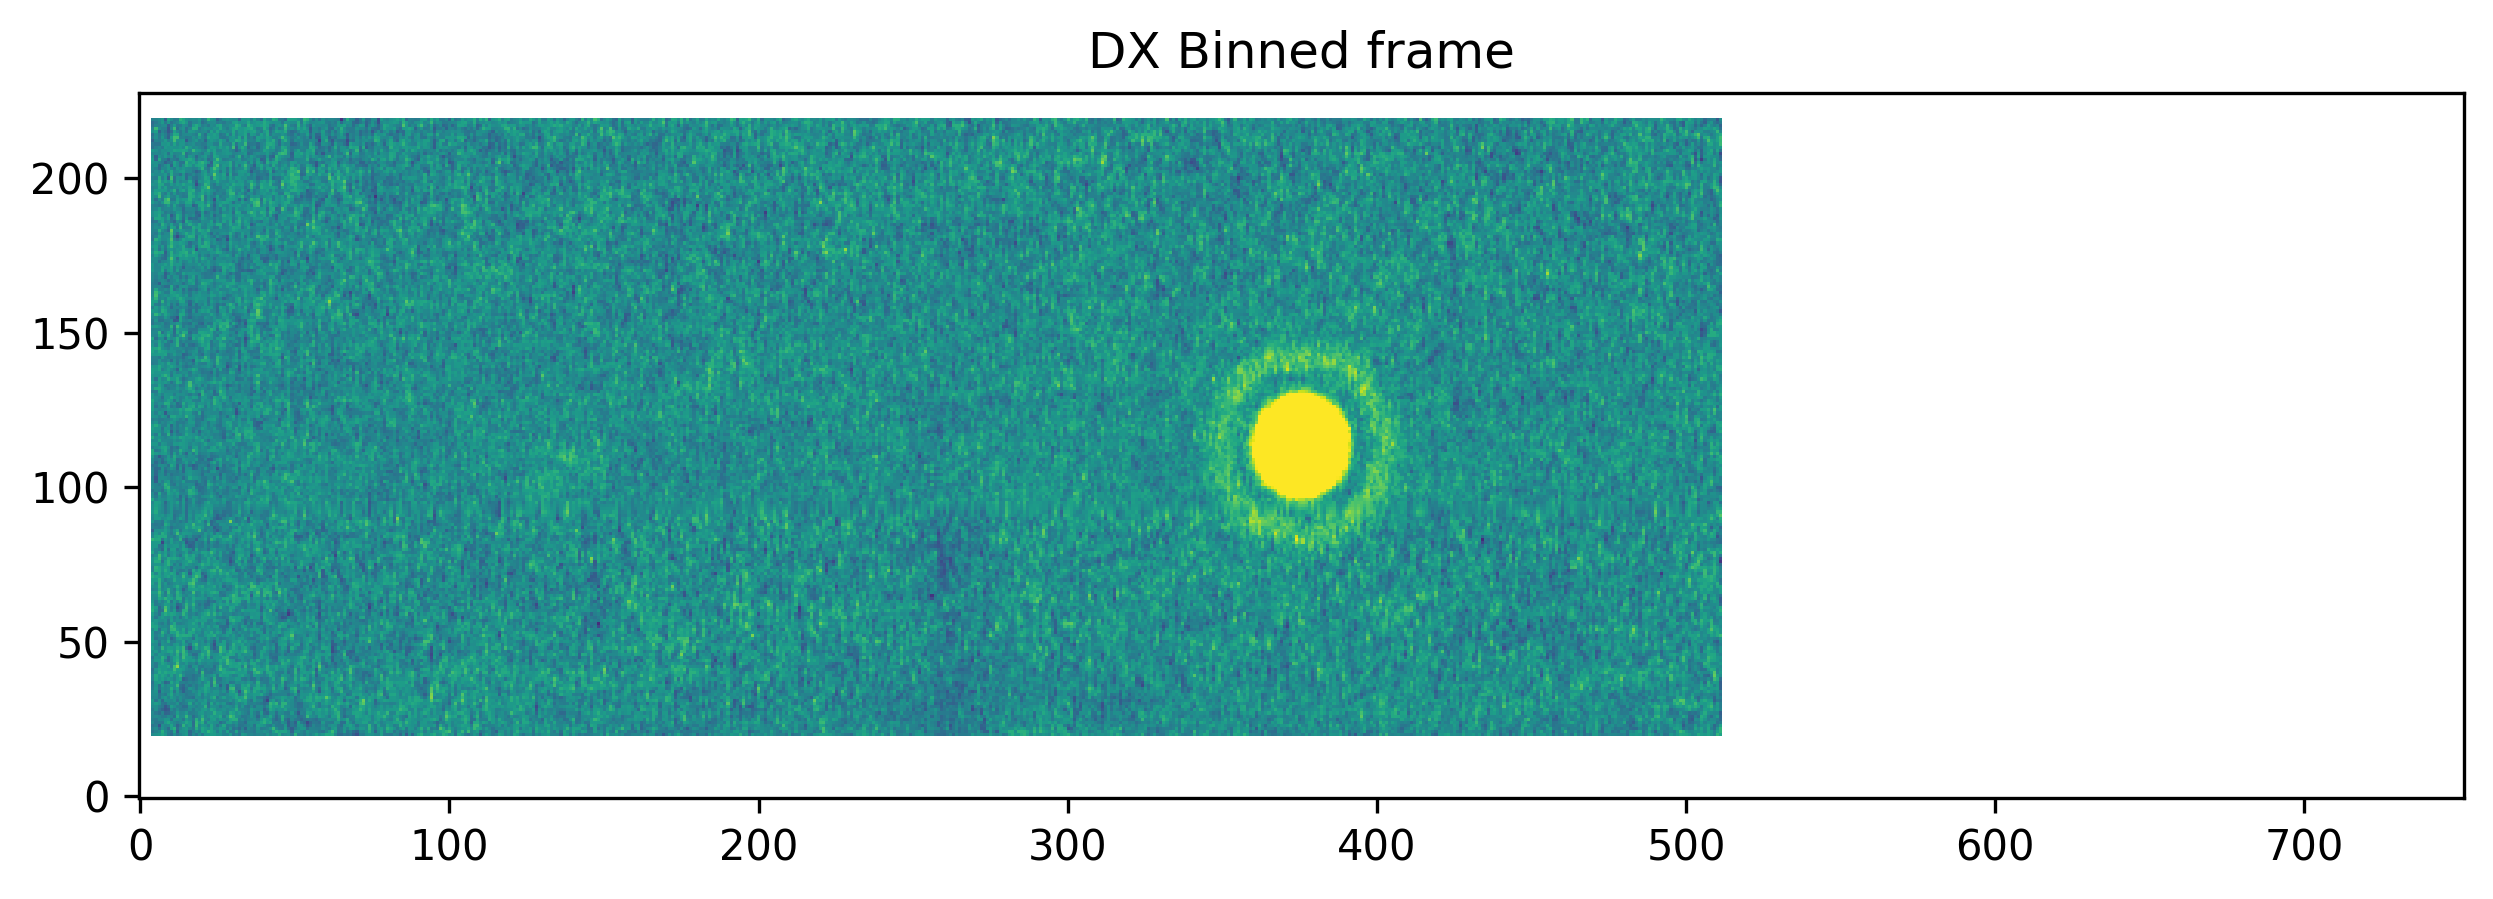

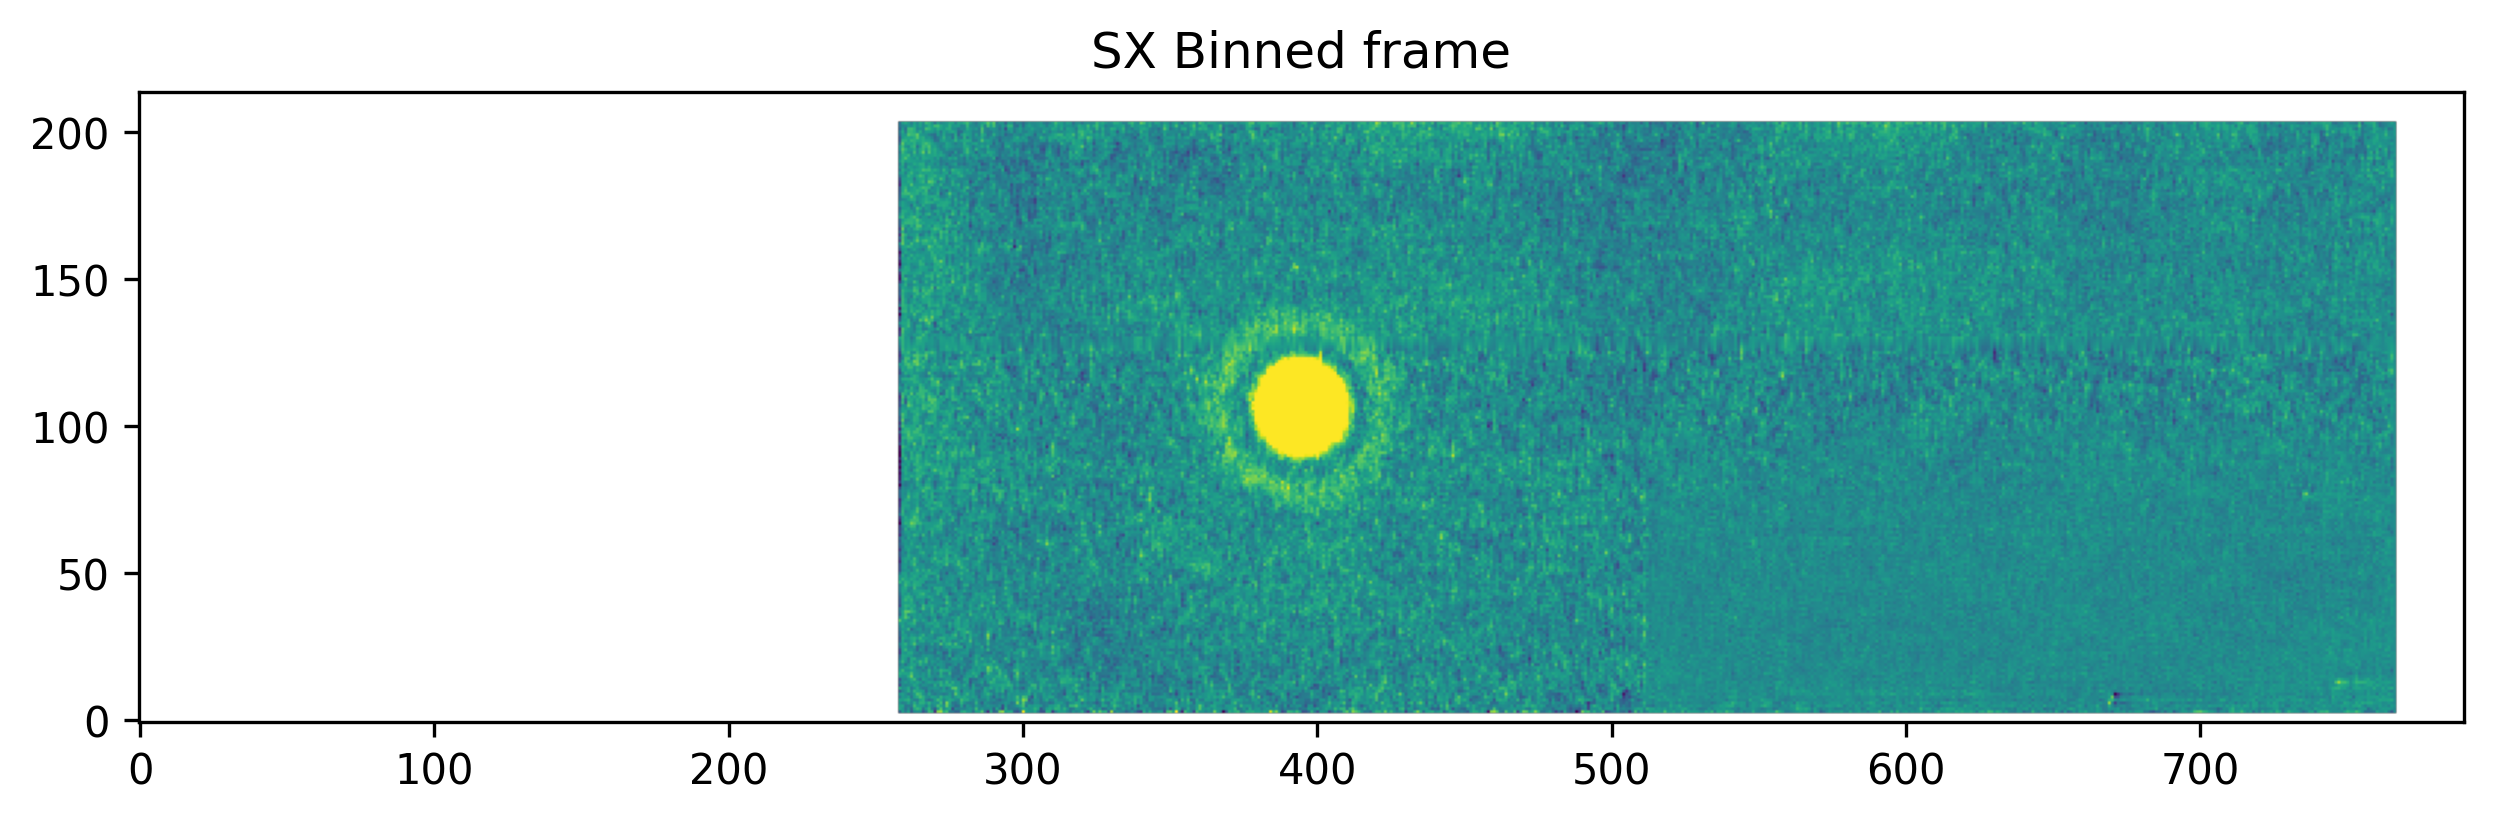

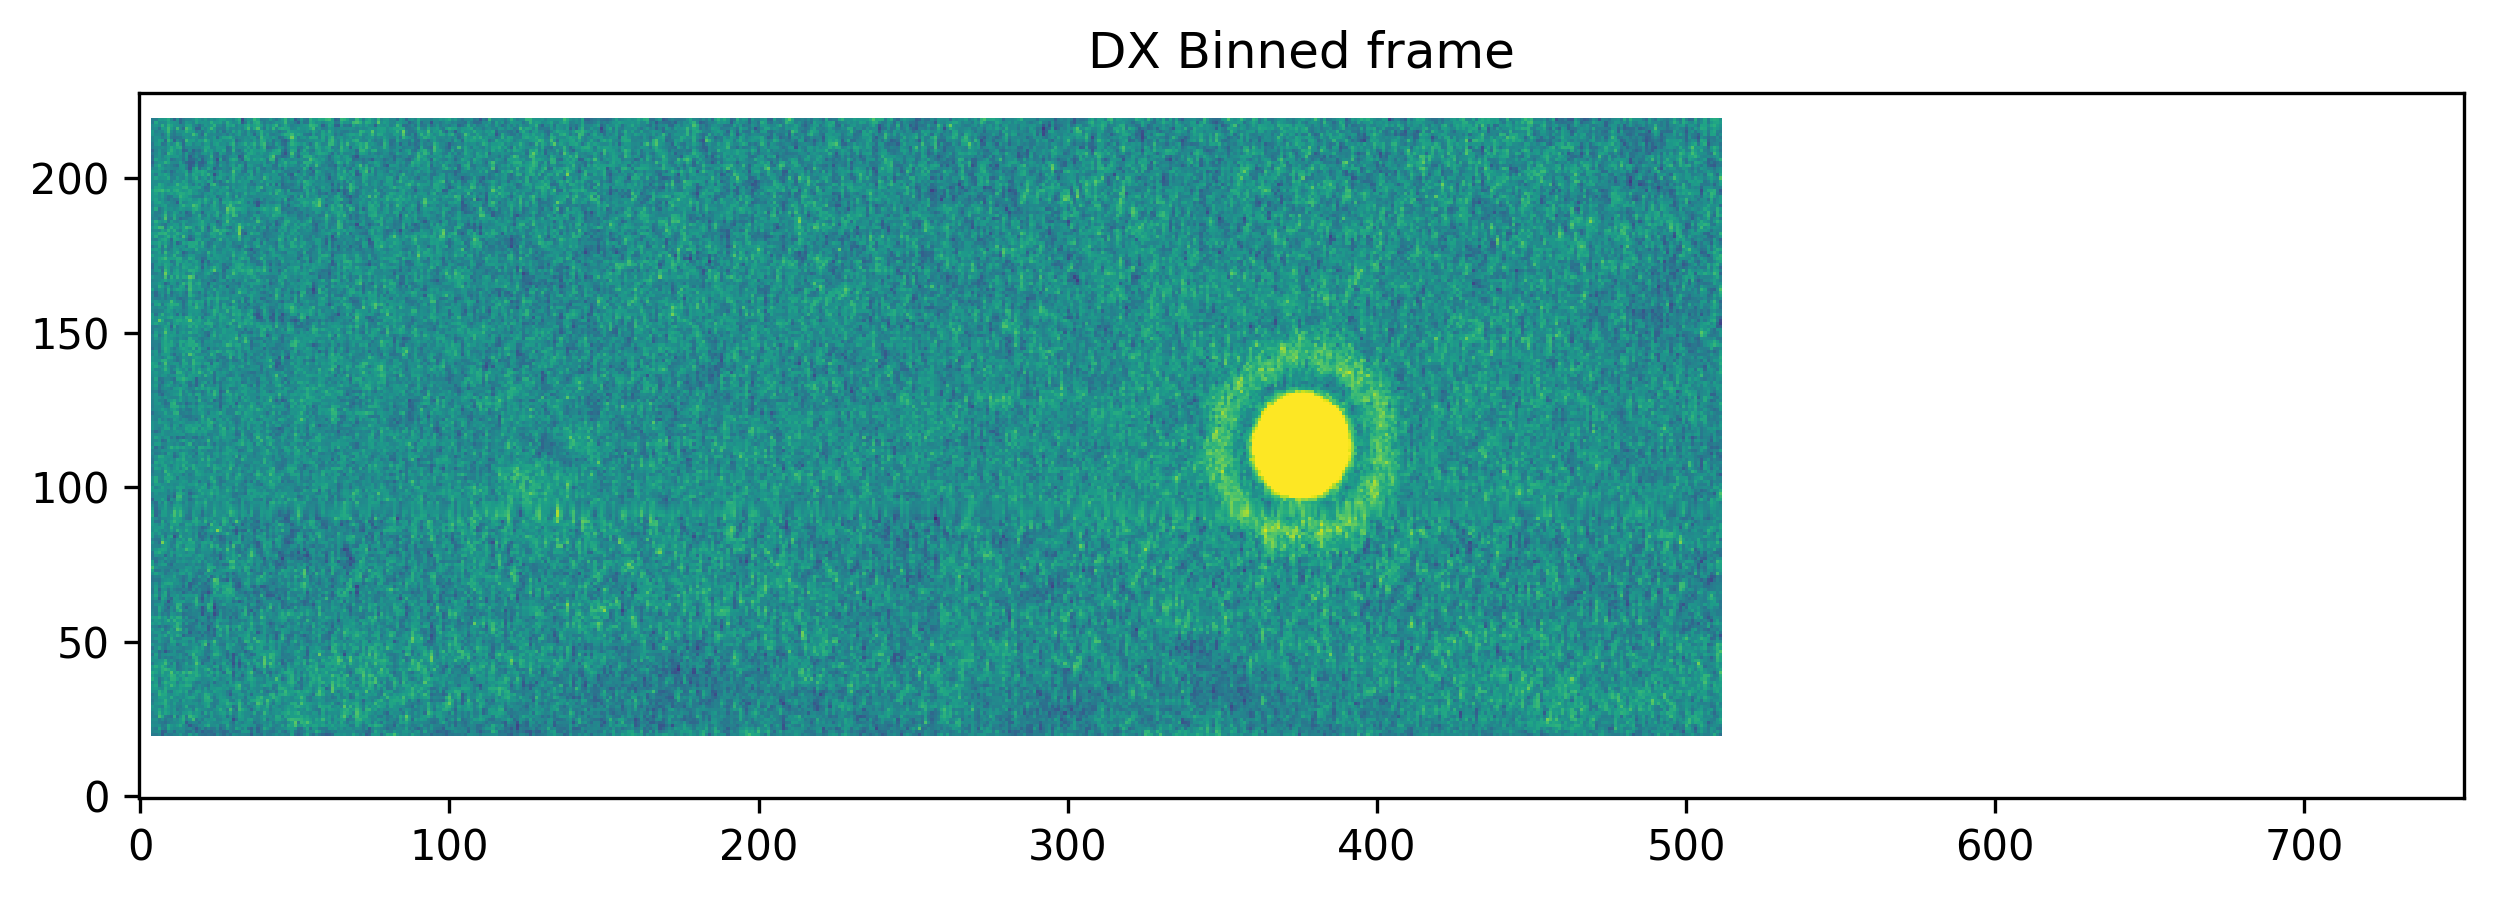

In [24]:
plt.figure(figsize=(10,10), dpi=300)
plt.title("SX Binned frame")
plt.imshow(sx_image_cube[0], origin="lower", vmin=-2e-5, vmax=2e-5)
plt.show()
plt.figure(figsize=(10,10), dpi=300)
plt.title("DX Binned frame")
plt.imshow(dx_image_cube[0], origin="lower", vmin=-2e-5, vmax=2e-5)
plt.show()
plt.figure(figsize=(10,10), dpi=300)
plt.title("SX Binned frame")
plt.imshow(sx_image_cube[1], origin="lower", vmin=-2e-5, vmax=2e-5)
plt.show()
plt.figure(figsize=(10,10), dpi=300)
plt.title("DX Binned frame")
plt.imshow(dx_image_cube[1], origin="lower", vmin=-2e-5, vmax=2e-5)
plt.show()